# Quality Prediction in a Mining Process

## Industrial Manufacturing and Production

### Objective
The objective of this project is to predict the **% Silica Concentrate** in the flotation process using machine learning techniques. Accurate prediction enables mining engineers to optimize operations, reduce impurities, minimize iron losses, and improve production efficiency.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv(
    r"D:\Quality Prediction in a Mining Process\MiningProcess_Flotation_Plant_Database.csv"
)

print("Dataset Loaded Successfully")
# ==========================================================
# CONVERT DECIMAL FORMAT
# ==========================================================

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Convert all remaining columns to float
for col in df.columns[1:]:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data Type Conversion Completed")

Dataset Loaded Successfully
Data Type Conversion Completed


In [4]:
# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("Dataset Shape :", df.shape)

display(df.head())

display(df.tail())

Dataset Shape : (737453, 24)


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,295.096,306.4,250.225,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,250.862,295.096,306.4,250.137,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,250.313,295.096,306.4,251.345,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,250.049,295.096,306.4,250.422,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,249.895,295.096,306.4,249.983,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
737448,2017-09-09 23:00:00,49.75,23.2,2710.94,441.052,386.570,9.62129,1.65365,302.344,298.786,299.163,299.920,299.623,346.794,313.695,392.160,430.702,872.008,418.725,497.548,446.357,416.892,64.27,1.71
737449,2017-09-09 23:00:00,49.75,23.2,2692.01,473.436,384.939,9.62063,1.65352,303.013,301.879,299.487,299.710,300.465,330.023,236.700,401.505,404.616,864.409,418.377,506.398,372.995,426.337,64.27,1.71
737450,2017-09-09 23:00:00,49.75,23.2,2692.20,500.488,383.496,9.61874,1.65338,303.662,307.397,299.487,299.927,299.707,329.590,225.879,408.899,399.316,867.598,419.531,503.414,336.035,433.130,64.27,1.71
737451,2017-09-09 23:00:00,49.75,23.2,1164.12,491.548,384.976,9.61686,1.65324,302.550,301.959,298.045,299.372,298.819,351.453,308.115,405.107,466.832,876.591,407.299,502.301,340.844,433.966,64.27,1.71
737452,2017-09-09 23:00:00,49.75,23.2,1164.12,468.019,384.801,9.61497,1.65310,300.355,292.865,298.625,298.717,297.395,362.464,308.115,413.754,514.143,881.323,378.969,500.100,374.354,441.182,64.27,1.71


In [5]:
# ==========================================================
# DATASET INFORMATION
# ==========================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          737453 non-null  datetime64[us]
 1   % Iron Feed                   737453 non-null  float64       
 2   % Silica Feed                 737453 non-null  float64       
 3   Starch Flow                   737453 non-null  float64       
 4   Amina Flow                    737453 non-null  float64       
 5   Ore Pulp Flow                 737453 non-null  float64       
 6   Ore Pulp pH                   737453 non-null  float64       
 7   Ore Pulp Density              737453 non-null  float64       
 8   Flotation Column 01 Air Flow  737453 non-null  float64       
 9   Flotation Column 02 Air Flow  737453 non-null  float64       
 10  Flotation Column 03 Air Flow  737453 non-null  float64       
 11  Flotation Column 04 Air 

In [6]:
# ==========================================================
# COLUMN NAMES
# ==========================================================

print(df.columns)

Index(['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='str')


In [7]:
# ==========================================================
# CHECK MISSING VALUES
# ==========================================================

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal Missing Values :", missing_values.sum())

date                            0
% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Iron Concentrate              0
% Silica Concentrate            0
dtype: int64

Total Missing Values : 0


In [9]:
# ==========================================================
# CHECK DUPLICATE VALUES
# ==========================================================

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 1171


In [10]:
df.drop_duplicates(inplace=True)

In [11]:
# ==========================================================
# CHECK DUPLICATE VALUES
# ==========================================================

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [12]:
# ==========================================================
# DATA TYPES
# ==========================================================

print(df.dtypes)

date                            datetime64[us]
% Iron Feed                            float64
% Silica Feed                          float64
Starch Flow                            float64
Amina Flow                             float64
Ore Pulp Flow                          float64
Ore Pulp pH                            float64
Ore Pulp Density                       float64
Flotation Column 01 Air Flow           float64
Flotation Column 02 Air Flow           float64
Flotation Column 03 Air Flow           float64
Flotation Column 04 Air Flow           float64
Flotation Column 05 Air Flow           float64
Flotation Column 06 Air Flow           float64
Flotation Column 07 Air Flow           float64
Flotation Column 01 Level              float64
Flotation Column 02 Level              float64
Flotation Column 03 Level              float64
Flotation Column 04 Level              float64
Flotation Column 05 Level              float64
Flotation Column 06 Level              float64
Flotation Col

In [13]:
# ==========================================================
# STATISTICAL SUMMARY
# ==========================================================

display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
date,736282,2017-06-16 02:30:44.009768,2017-03-10 01:00:00,2017-05-04 21:00:00,2017-06-16 12:00:00,2017-07-29 09:00:00,2017-09-09 23:00:00,NaN
% Iron Feed,736282.0,56.298307,42.74,52.67,56.08,59.72,65.78,5.160365
% Silica Feed,736282.0,14.648984,1.31,8.94,13.85,19.6,33.4,6.810741
Starch Flow,736282.0,2869.636615,0.002026,2075.07,3020.23,3728.93,6300.23,1216.017896
Amina Flow,736282.0,488.165523,241.669,431.835848,504.3525,553.33575,739.538,91.254428
Ore Pulp Flow,736282.0,397.570736,376.249,394.248,399.238,402.967,418.641,9.705444
Ore Pulp pH,736282.0,9.767315,8.75334,9.52705,9.79746,10.0378,10.8081,0.387176
Ore Pulp Density,736282.0,1.680424,1.51982,1.64739,1.69758,1.72838,1.85325,0.069206
Flotation Column 01 Air Flow,736282.0,280.119813,175.51,250.278,299.341,300.147,373.871,29.633831
Flotation Column 02 Air Flow,736282.0,277.121249,175.156,250.448,296.202,300.686,375.992,30.157126


In [14]:
# ==========================================================
# SAVE CLEAN DATASET
# ==========================================================

df.to_csv(
    "Mining_Cleaned_Dataset.csv",
    index=False
)

print("Clean Dataset Saved Successfully!")

Clean Dataset Saved Successfully!


PART 2: Exploratory Data Analysis (EDA)

In [15]:
# ==========================================================
# IMPORT VISUALIZATION LIBRARIES
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_style("whitegrid")

print("Visualization Libraries Loaded Successfully!")

Visualization Libraries Loaded Successfully!


In [16]:
# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

display(df.head())

display(df.tail())

Number of Rows : 736282
Number of Columns : 24


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,295.096,306.4,250.225,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,250.862,295.096,306.4,250.137,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,250.313,295.096,306.4,251.345,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,250.049,295.096,306.4,250.422,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,249.895,295.096,306.4,249.983,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
737448,2017-09-09 23:00:00,49.75,23.2,2710.94,441.052,386.570,9.62129,1.65365,302.344,298.786,299.163,299.920,299.623,346.794,313.695,392.160,430.702,872.008,418.725,497.548,446.357,416.892,64.27,1.71
737449,2017-09-09 23:00:00,49.75,23.2,2692.01,473.436,384.939,9.62063,1.65352,303.013,301.879,299.487,299.710,300.465,330.023,236.700,401.505,404.616,864.409,418.377,506.398,372.995,426.337,64.27,1.71
737450,2017-09-09 23:00:00,49.75,23.2,2692.20,500.488,383.496,9.61874,1.65338,303.662,307.397,299.487,299.927,299.707,329.590,225.879,408.899,399.316,867.598,419.531,503.414,336.035,433.130,64.27,1.71
737451,2017-09-09 23:00:00,49.75,23.2,1164.12,491.548,384.976,9.61686,1.65324,302.550,301.959,298.045,299.372,298.819,351.453,308.115,405.107,466.832,876.591,407.299,502.301,340.844,433.966,64.27,1.71
737452,2017-09-09 23:00:00,49.75,23.2,1164.12,468.019,384.801,9.61497,1.65310,300.355,292.865,298.625,298.717,297.395,362.464,308.115,413.754,514.143,881.323,378.969,500.100,374.354,441.182,64.27,1.71


In [17]:
# ==========================================================
# STATISTICAL SUMMARY
# ==========================================================

display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
date,736282,2017-06-16 02:30:44.009768,2017-03-10 01:00:00,2017-05-04 21:00:00,2017-06-16 12:00:00,2017-07-29 09:00:00,2017-09-09 23:00:00,NaN
% Iron Feed,736282.0,56.298307,42.74,52.67,56.08,59.72,65.78,5.160365
% Silica Feed,736282.0,14.648984,1.31,8.94,13.85,19.6,33.4,6.810741
Starch Flow,736282.0,2869.636615,0.002026,2075.07,3020.23,3728.93,6300.23,1216.017896
Amina Flow,736282.0,488.165523,241.669,431.835848,504.3525,553.33575,739.538,91.254428
Ore Pulp Flow,736282.0,397.570736,376.249,394.248,399.238,402.967,418.641,9.705444
Ore Pulp pH,736282.0,9.767315,8.75334,9.52705,9.79746,10.0378,10.8081,0.387176
Ore Pulp Density,736282.0,1.680424,1.51982,1.64739,1.69758,1.72838,1.85325,0.069206
Flotation Column 01 Air Flow,736282.0,280.119813,175.51,250.278,299.341,300.147,373.871,29.633831
Flotation Column 02 Air Flow,736282.0,277.121249,175.156,250.448,296.202,300.686,375.992,30.157126


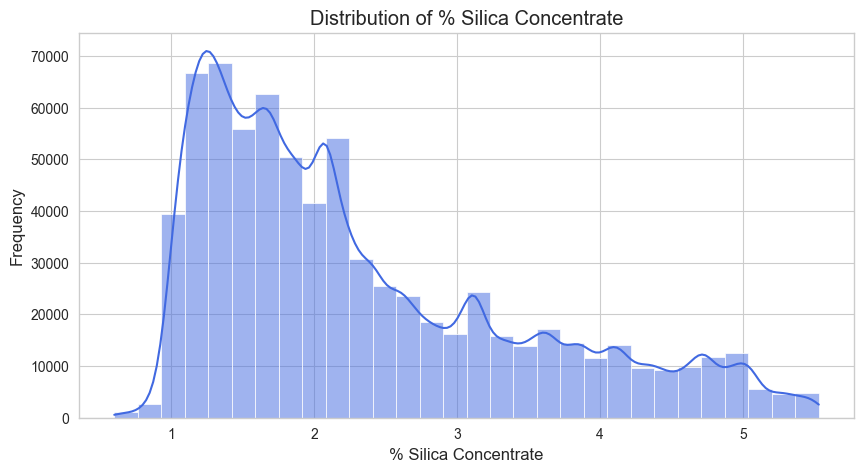

In [18]:
# ==========================================================
# DISTRIBUTION OF TARGET VARIABLE
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df['% Silica Concentrate'],
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title("Distribution of % Silica Concentrate")

plt.xlabel("% Silica Concentrate")

plt.ylabel("Frequency")

plt.show()

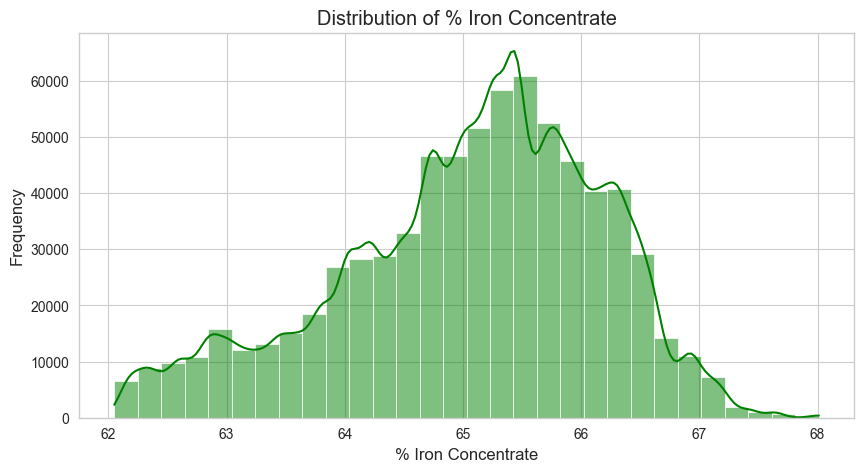

In [19]:
# ==========================================================
# DISTRIBUTION OF IRON CONCENTRATE
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df['% Iron Concentrate'],
    bins=30,
    kde=True,
    color='green'
)

plt.title("Distribution of % Iron Concentrate")

plt.xlabel("% Iron Concentrate")

plt.ylabel("Frequency")

plt.show()

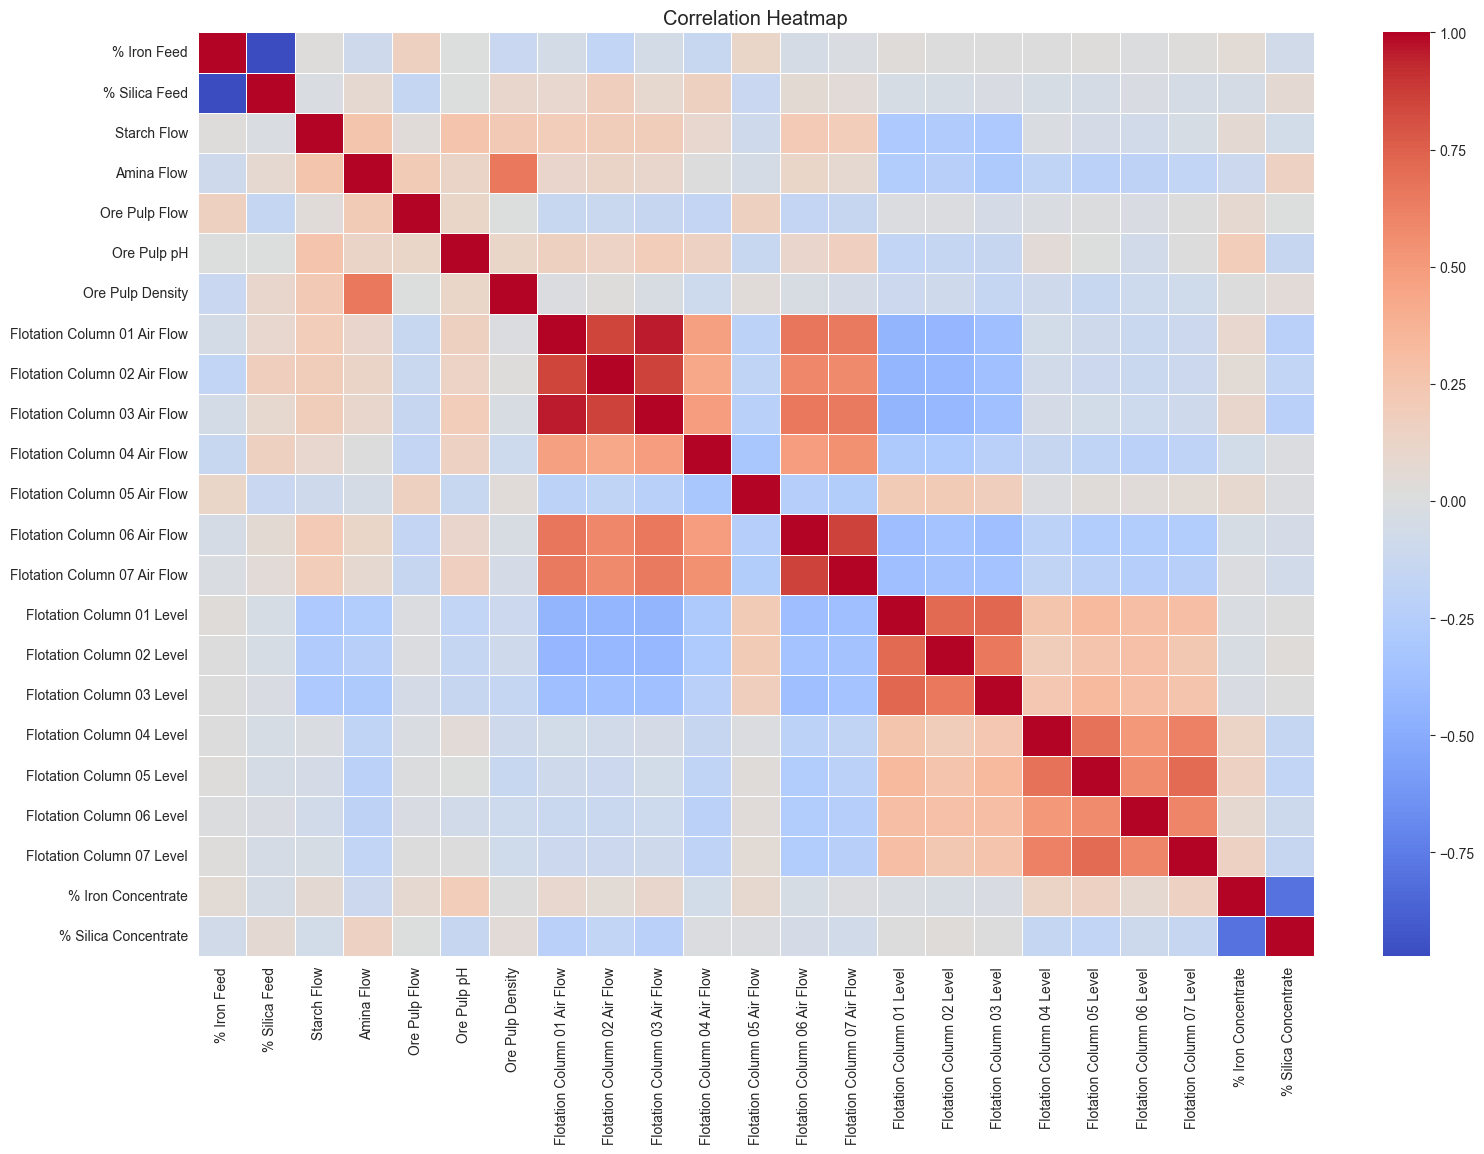

In [20]:
# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(18,12))

corr = df.drop(columns=['date']).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [21]:
# ==========================================================
# CORRELATION WITH TARGET
# ==========================================================

target_corr = corr["% Silica Concentrate"].sort_values(
    ascending=False
)

display(target_corr)

% Silica Concentrate            1.000000
Amina Flow                      0.156981
% Silica Feed                   0.072676
Ore Pulp Density                0.047002
Flotation Column 02 Level       0.031790
Flotation Column 01 Level       0.017859
Flotation Column 03 Level       0.014843
Ore Pulp Flow                   0.008497
Flotation Column 04 Air Flow   -0.004770
Flotation Column 05 Air Flow   -0.008930
Flotation Column 06 Air Flow   -0.049692
Starch Flow                    -0.066813
Flotation Column 07 Air Flow   -0.071685
% Iron Feed                    -0.077179
Flotation Column 06 Level      -0.102115
Flotation Column 07 Level      -0.140819
Ore Pulp pH                    -0.147211
Flotation Column 04 Level      -0.148886
Flotation Column 02 Air Flow   -0.167259
Flotation Column 05 Level      -0.168466
Flotation Column 03 Air Flow   -0.218834
Flotation Column 01 Air Flow   -0.219076
% Iron Concentrate             -0.800598
Name: % Silica Concentrate, dtype: float64

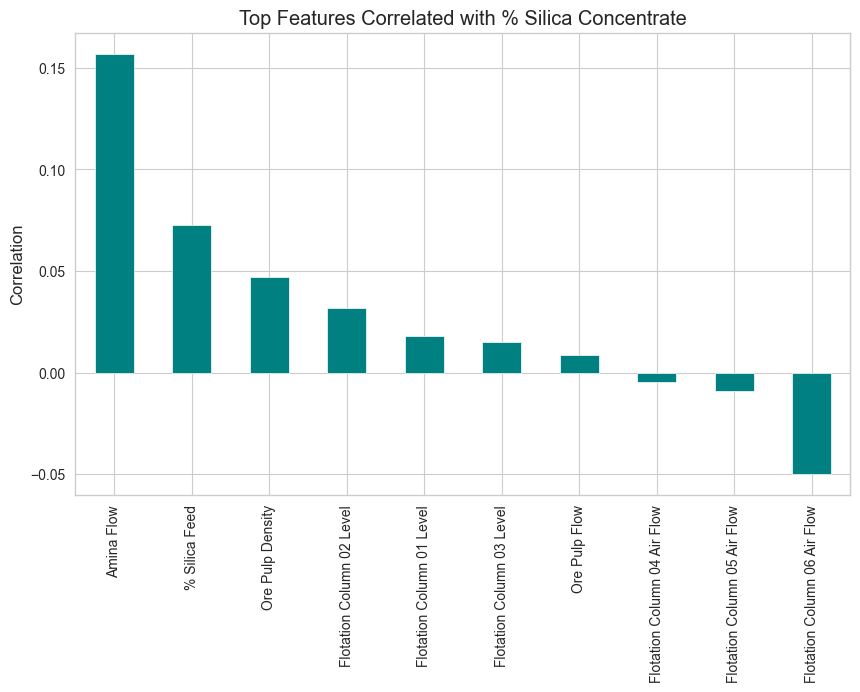

In [22]:
# ==========================================================
# TOP 10 FEATURES
# ==========================================================

plt.figure(figsize=(10,6))

target_corr.drop("% Silica Concentrate").head(10).plot(
    kind='bar',
    color='teal'
)

plt.ylabel("Correlation")

plt.title("Top Features Correlated with % Silica Concentrate")

plt.show()

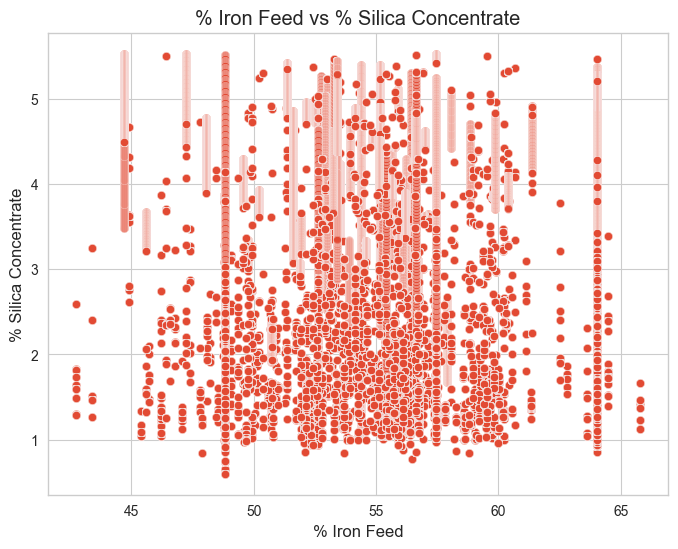

In [23]:
# ==========================================================
# IRON FEED VS SILICA CONCENTRATE
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="% Iron Feed",
    y="% Silica Concentrate",
    alpha=0.5
)

plt.title("% Iron Feed vs % Silica Concentrate")

plt.show()

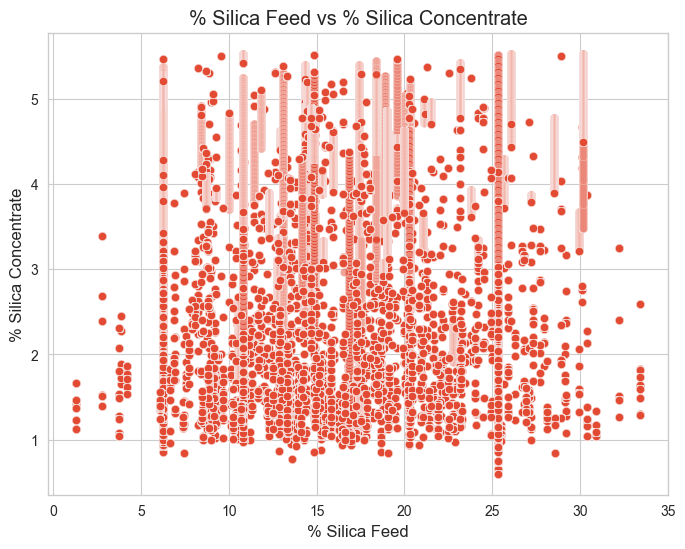

In [24]:
# ==========================================================
# SILICA FEED VS SILICA CONCENTRATE
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="% Silica Feed",
    y="% Silica Concentrate",
    alpha=0.5
)

plt.title("% Silica Feed vs % Silica Concentrate")

plt.show()

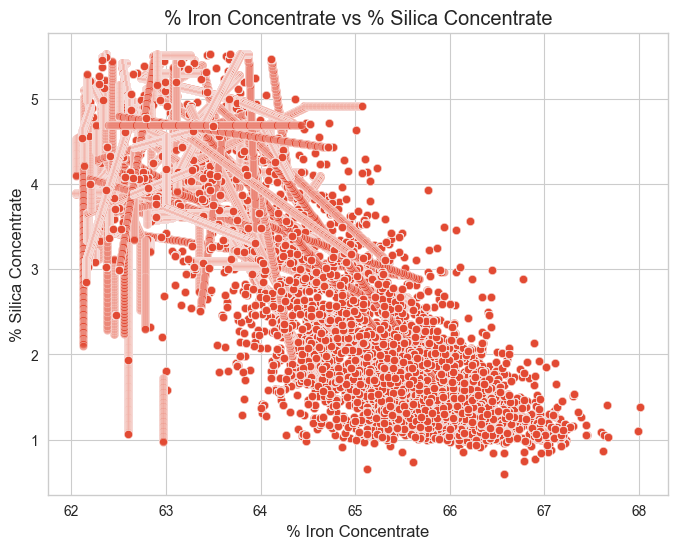

In [25]:
# ==========================================================
# IRON CONCENTRATE VS SILICA CONCENTRATE
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="% Iron Concentrate",
    y="% Silica Concentrate",
    alpha=0.5
)

plt.title("% Iron Concentrate vs % Silica Concentrate")

plt.show()

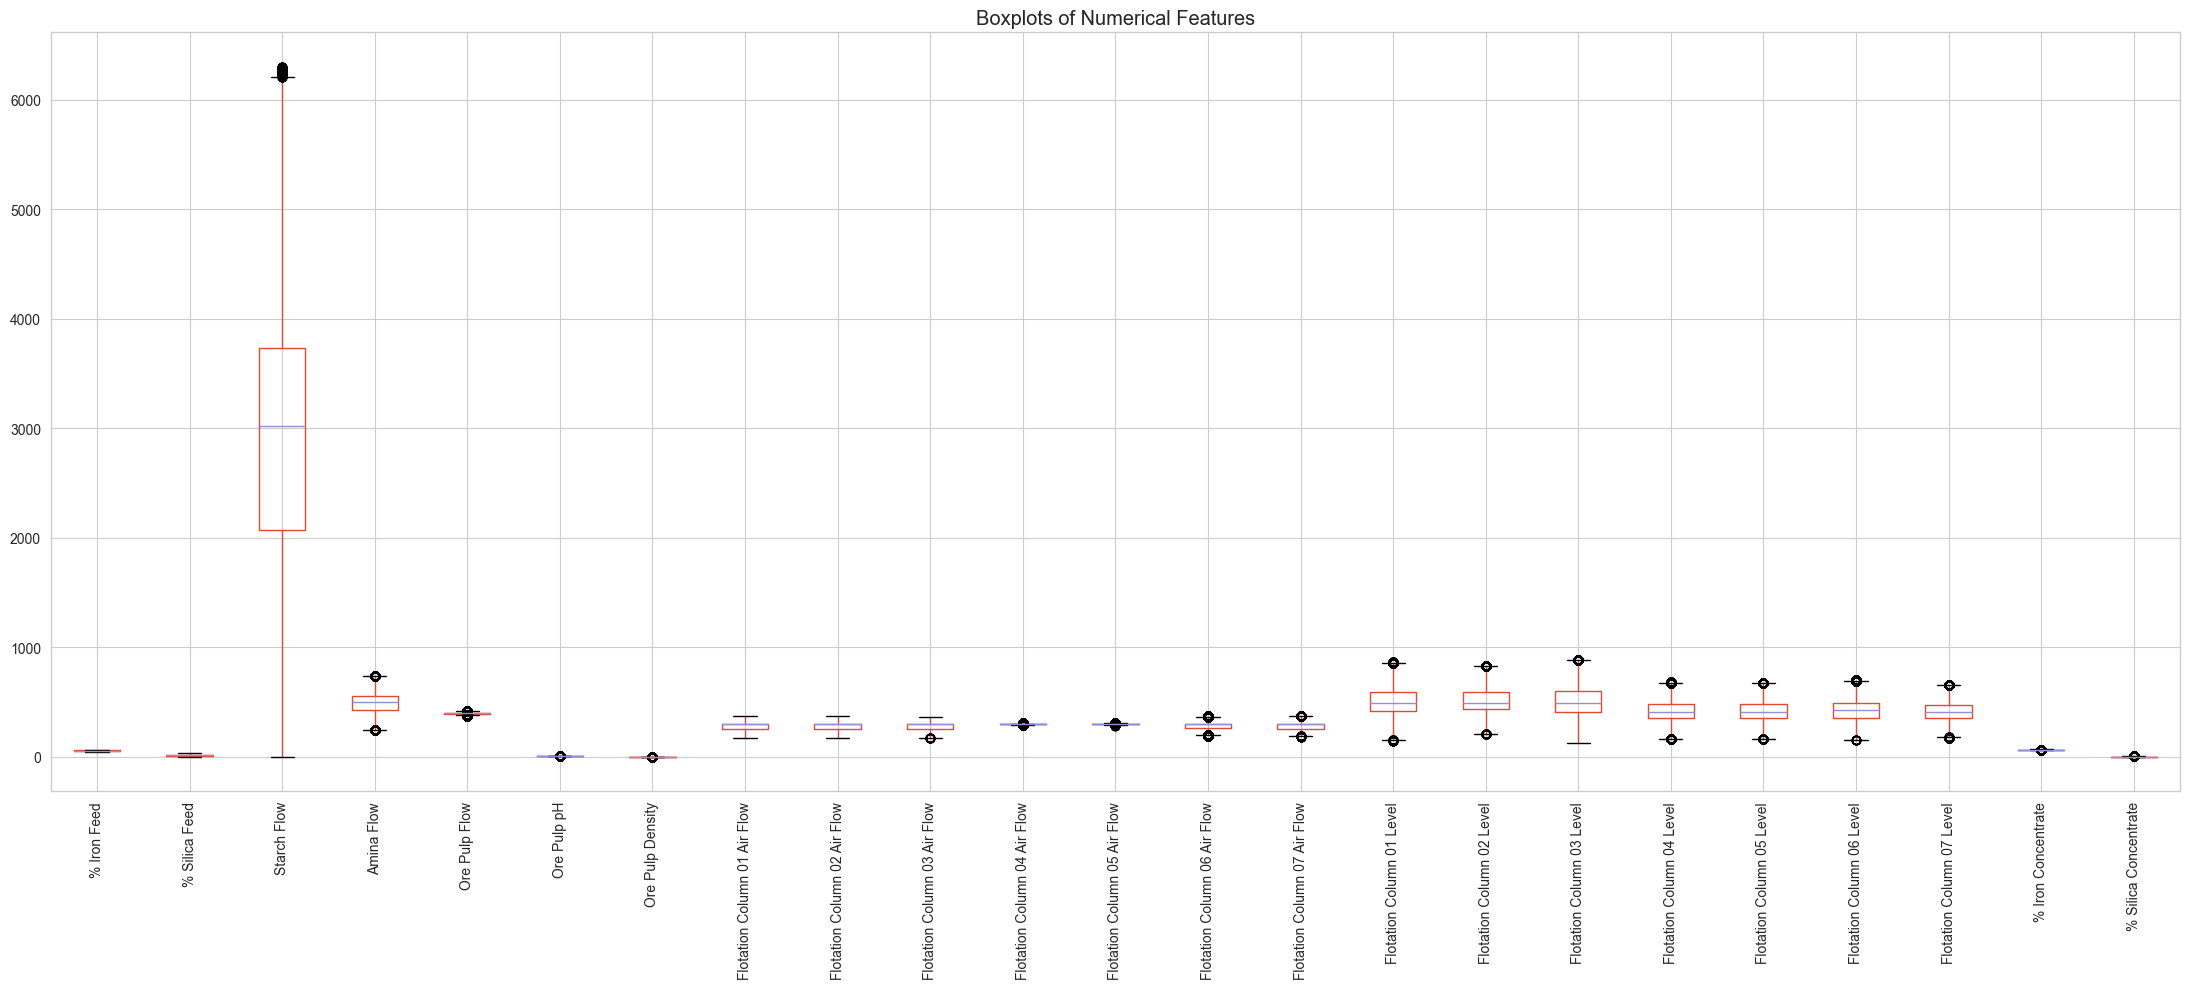

In [26]:
# ==========================================================
# BOXPLOTS
# ==========================================================

plt.figure(figsize=(22,10))

df.drop(columns=['date']).boxplot(rot=90)

plt.title("Boxplots of Numerical Features")

plt.tight_layout()

plt.show()

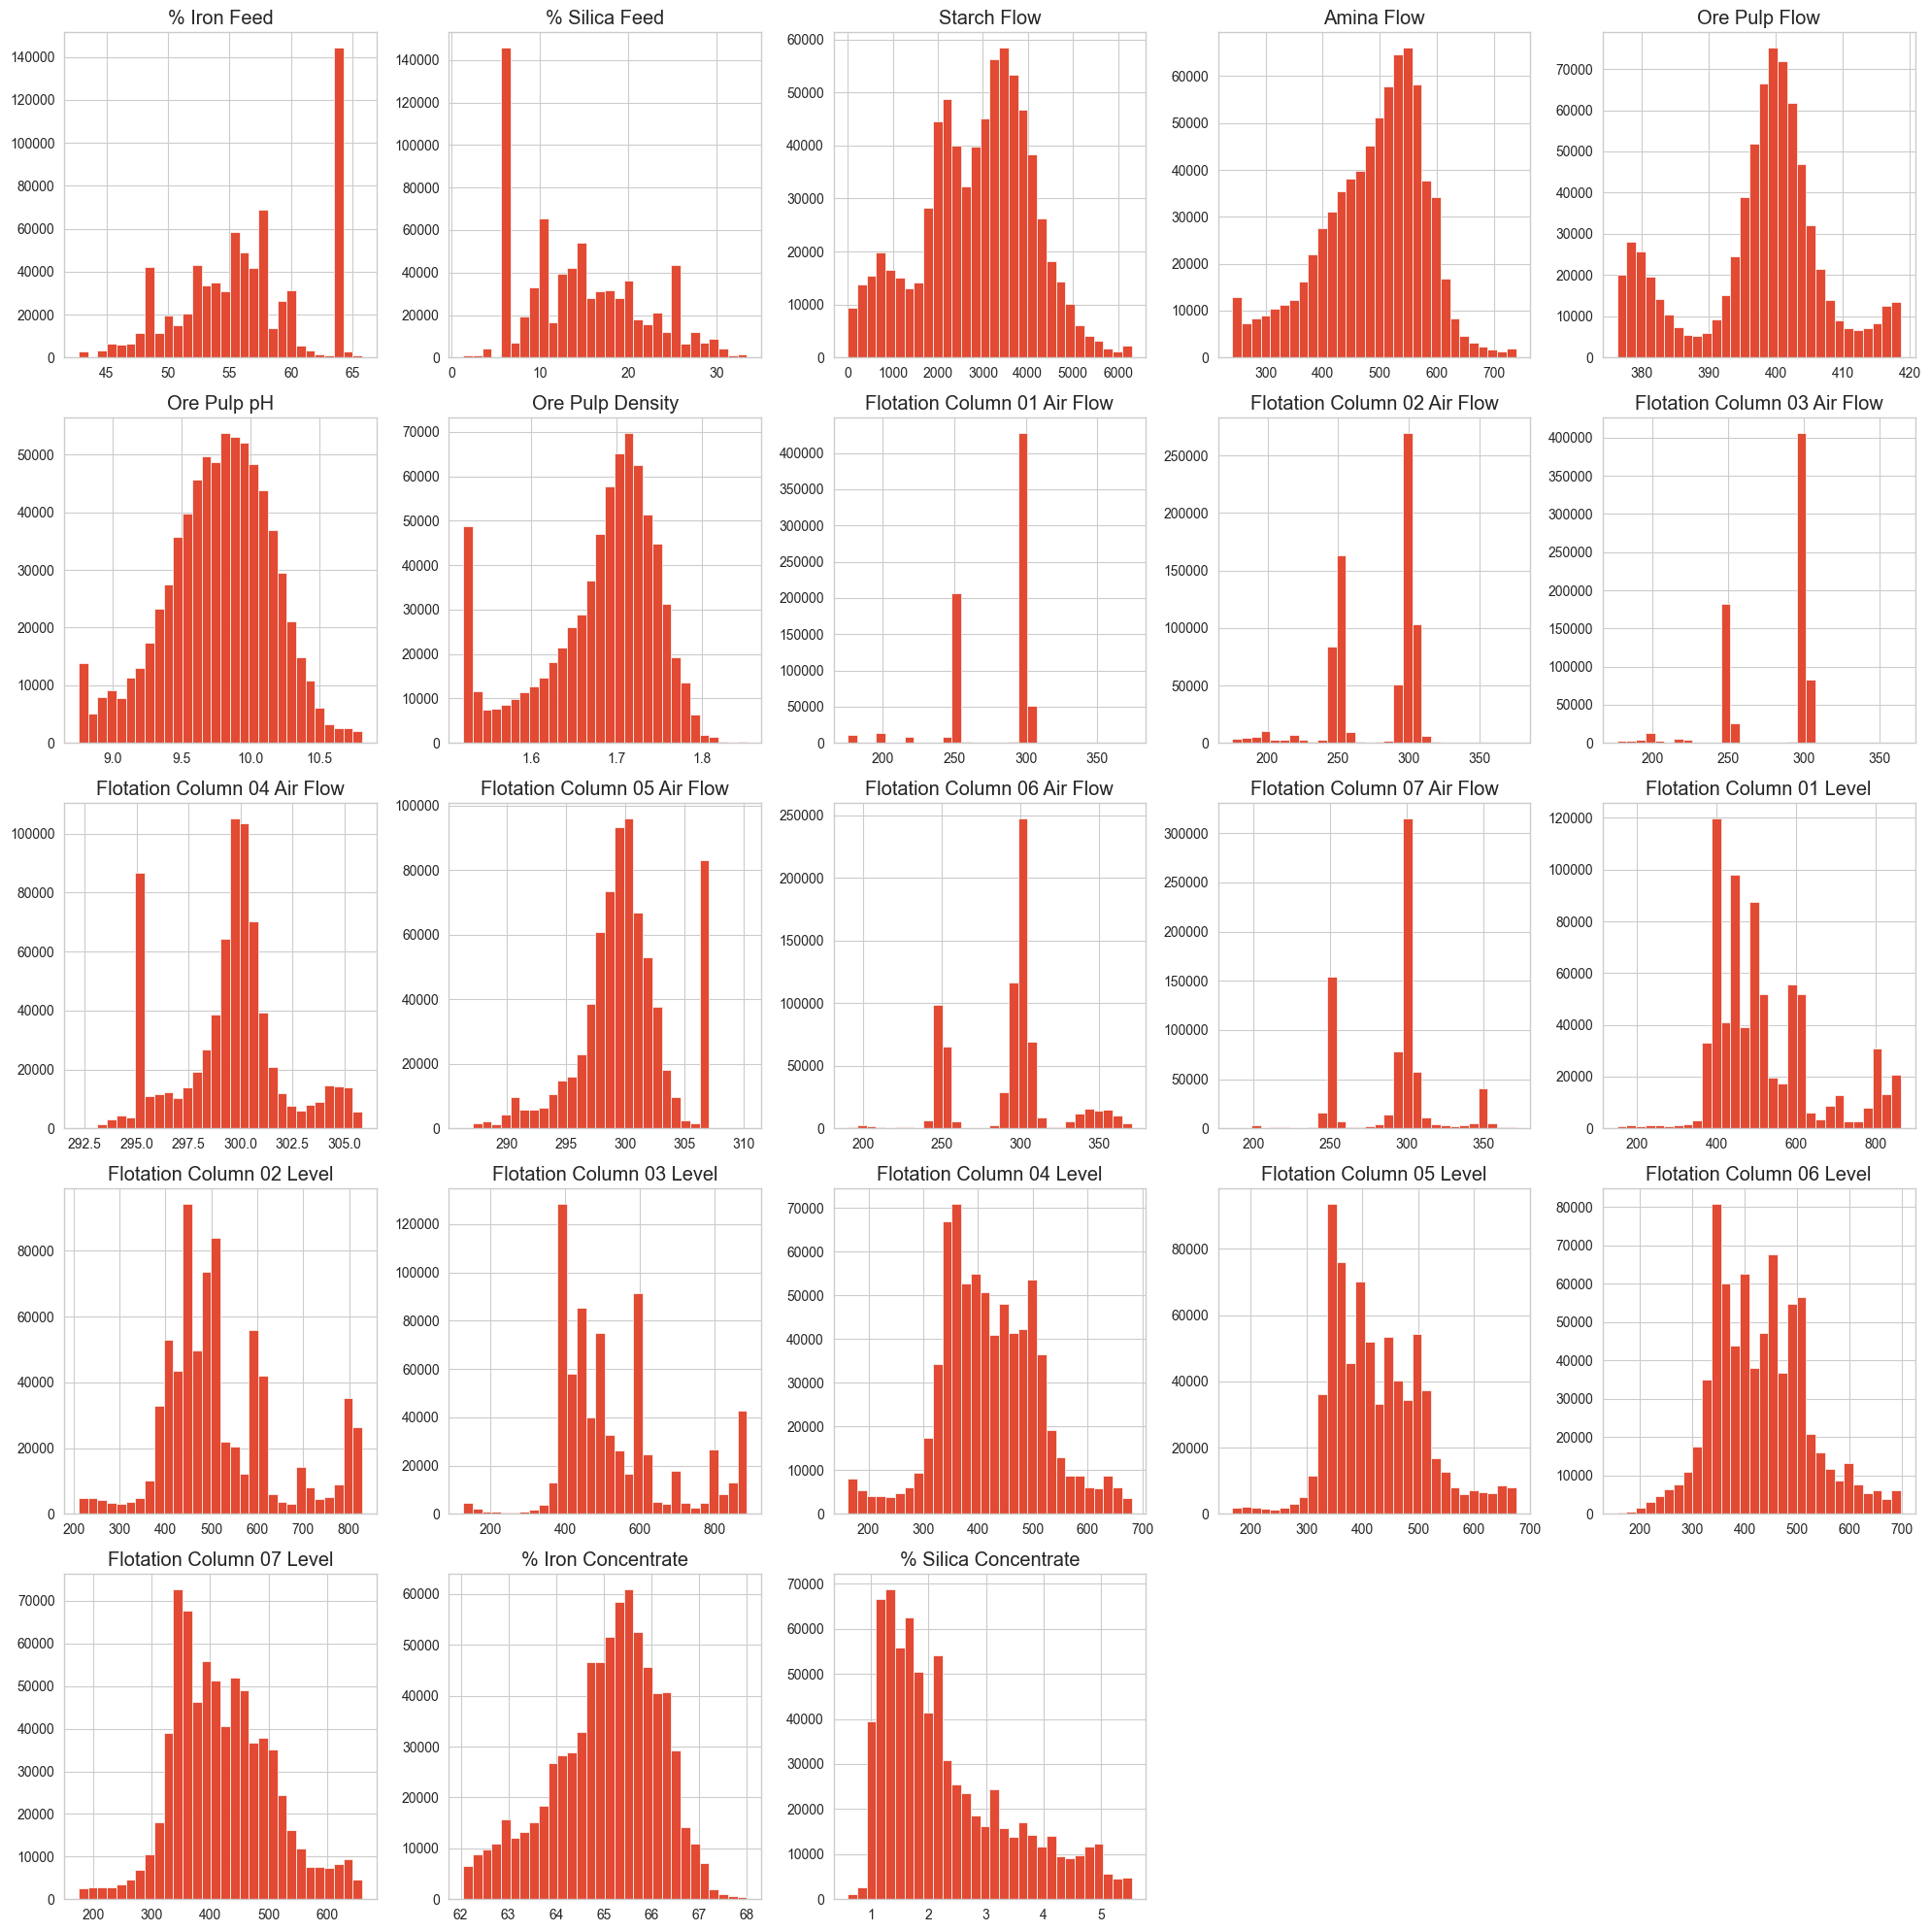

In [27]:
# ==========================================================
# HISTOGRAMS
# ==========================================================

df.drop(columns=['date']).hist(
    figsize=(20,20),
    bins=30
)

plt.tight_layout()

plt.show()

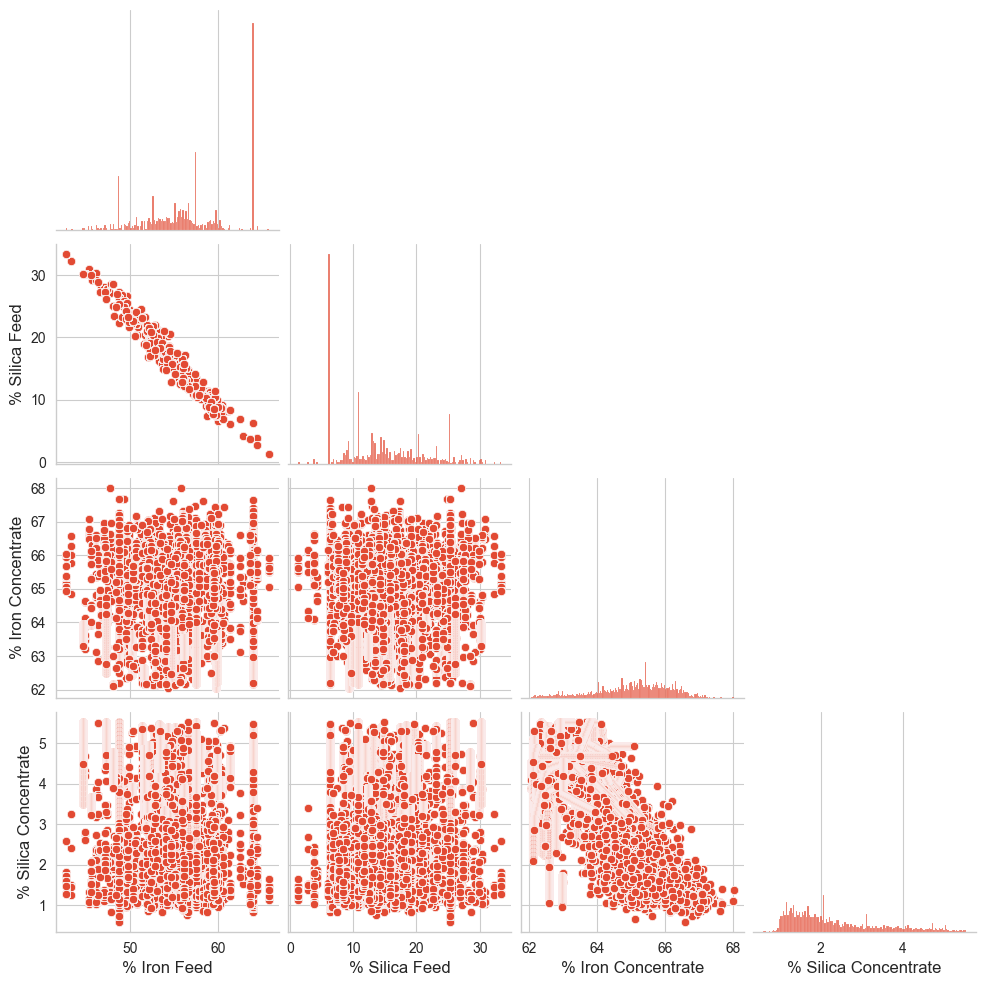

In [28]:
# ==========================================================
# PAIRPLOT
# ==========================================================

pairplot_columns = [

    "% Iron Feed",

    "% Silica Feed",

    "% Iron Concentrate",

    "% Silica Concentrate"

]

sns.pairplot(
    df[pairplot_columns],
    corner=True
)

plt.show()

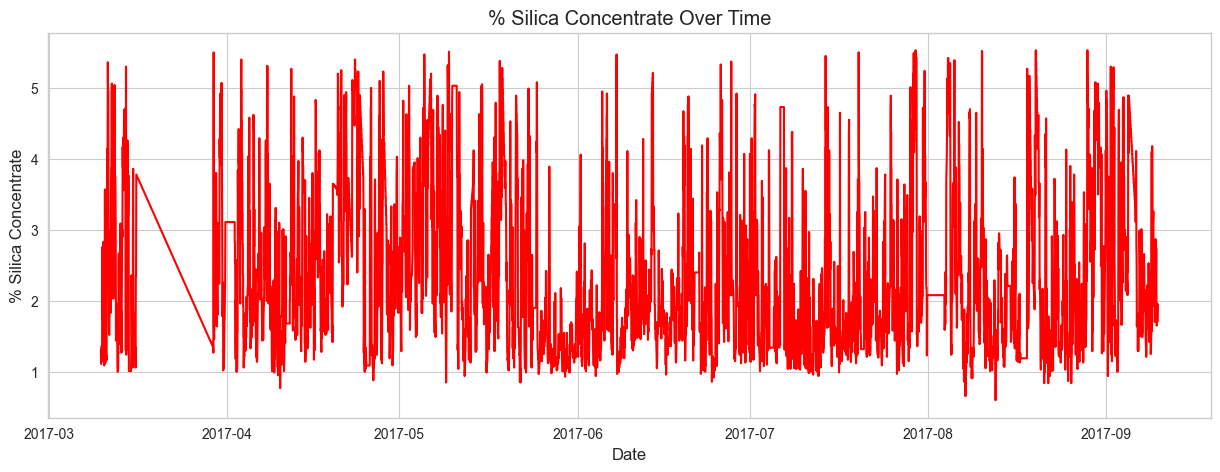

In [29]:
# ==========================================================
# SILICA CONCENTRATE OVER TIME
# ==========================================================

plt.figure(figsize=(15,5))

plt.plot(
    df["date"],
    df["% Silica Concentrate"],
    color='red'
)

plt.title("% Silica Concentrate Over Time")

plt.xlabel("Date")

plt.ylabel("% Silica Concentrate")

plt.show()

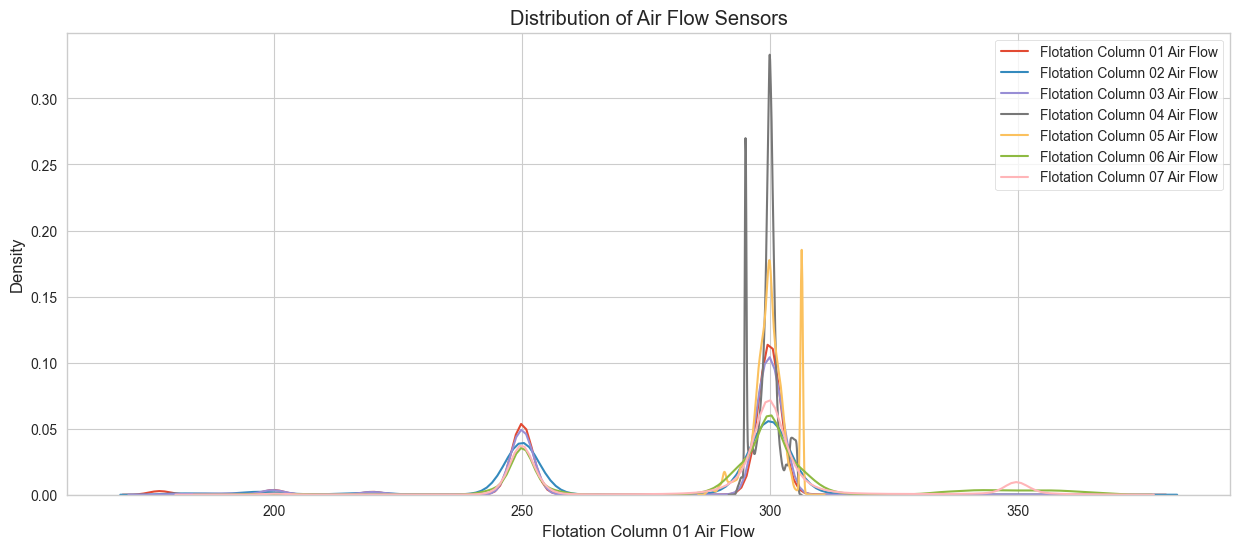

In [30]:
# ==========================================================
# AIR FLOW DISTRIBUTION
# ==========================================================

air_columns = [

    col for col in df.columns

    if "Air Flow" in col

]

plt.figure(figsize=(15,6))

for column in air_columns:

    sns.kdeplot(
        df[column],
        label=column
    )

plt.title("Distribution of Air Flow Sensors")

plt.legend()

plt.show()

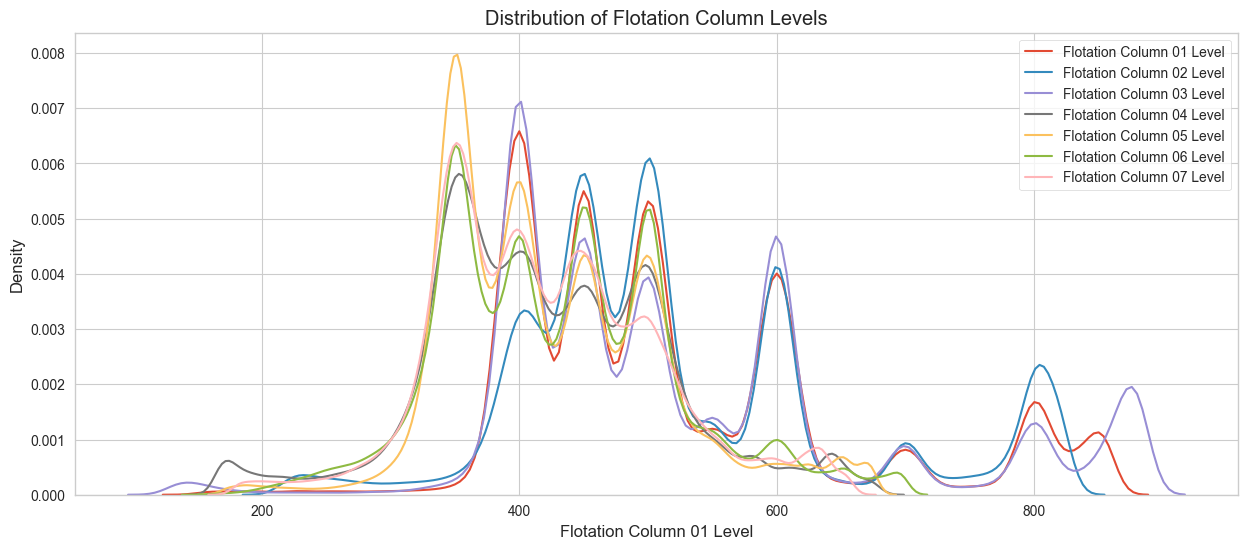

In [31]:
# ==========================================================
# FLOTATION LEVELS
# ==========================================================

level_columns = [

    col for col in df.columns

    if "Level" in col

]

plt.figure(figsize=(15,6))

for column in level_columns:

    sns.kdeplot(
        df[column],
        label=column
    )

plt.title("Distribution of Flotation Column Levels")

plt.legend()

plt.show()

In [32]:
print("="*60)
print("EDA SUMMARY")
print("="*60)

print("Dataset Shape :", df.shape)

print("Missing Values :", df.isnull().sum().sum())

print("Duplicate Rows :", df.duplicated().sum())

print("\nTarget Variable Statistics")

print(df["% Silica Concentrate"].describe())

EDA SUMMARY
Dataset Shape : (736282, 24)
Missing Values : 0
Duplicate Rows : 0

Target Variable Statistics
count    736282.000000
mean          2.327270
std           1.125616
min           0.600000
25%           1.440000
50%           2.000000
75%           3.010000
max           5.530000
Name: % Silica Concentrate, dtype: float64


📘 PART 3: Feature Engineering

In [33]:
# ==========================================================
# CREATE A COPY OF THE DATASET
# ==========================================================

data = df.copy()

print("Dataset copied successfully!")

Dataset copied successfully!


In [34]:
# ==========================================================
# EXTRACT DATE FEATURES
# ==========================================================

data["Year"] = data["date"].dt.year
data["Month"] = data["date"].dt.month
data["Day"] = data["date"].dt.day
data["Hour"] = data["date"].dt.hour
data["Minute"] = data["date"].dt.minute
data["DayOfWeek"] = data["date"].dt.dayofweek

display(data.head())

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate,Year,Month,Day,Hour,Minute,DayOfWeek
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,295.096,306.4,250.225,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31,2017,3,10,1,0,4
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,250.862,295.096,306.4,250.137,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31,2017,3,10,1,0,4
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,250.313,295.096,306.4,251.345,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31,2017,3,10,1,0,4
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,250.049,295.096,306.4,250.422,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31,2017,3,10,1,0,4
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,249.895,295.096,306.4,249.983,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31,2017,3,10,1,0,4


In [35]:
# ==========================================================
# REMOVE DATE COLUMN
# ==========================================================

data.drop("date", axis=1, inplace=True)

print("Date column removed successfully!")

Date column removed successfully!


In [36]:
# ==========================================================
# CREATE FEATURES AND TARGET
# ==========================================================

X = data.drop("% Silica Concentrate", axis=1)

y = data["% Silica Concentrate"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (736282, 28)
Target Shape : (736282,)


In [37]:
# ==========================================================
# FEATURE NAMES
# ==========================================================

print(X.columns)

Index(['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', 'Year', 'Month', 'Day', 'Hour', 'Minute',
       'DayOfWeek'],
      dtype='str')


In [38]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (589025, 28)
Testing Shape : (147257, 28)


In [39]:
# ==========================================================
# FEATURE SCALING
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [40]:
# ==========================================================
# CONVERT TO DATAFRAME
# ==========================================================

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

display(X_train_scaled.head())

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,Year,Month,Day,Hour,Minute,DayOfWeek
0,-0.967346,1.447431,-0.121605,-0.113757,0.094220,0.921005,0.968670,-1.020316,-0.859397,-1.119942,0.264630,0.227886,0.332550,0.126638,-0.458713,-0.633790,-0.579951,-0.899143,-0.807610,-1.119951,-0.921884,-1.170381,0.0,-0.614482,-0.932138,0.503113,0.0,1.496707
1,-0.626534,0.678626,0.376903,0.681720,-1.953764,-0.620984,0.620640,0.648303,0.622373,0.609416,-0.046215,0.622496,0.365873,0.307486,-0.252458,-0.151382,0.430712,-0.103984,-1.140322,-0.088570,-1.404004,0.643805,0.0,1.201600,0.857947,-1.084524,0.0,-0.510234
2,-0.959601,1.247894,-2.000226,-0.716536,-2.165498,0.187527,-0.769315,0.665509,0.853589,0.734556,2.323787,-2.526966,1.631572,2.051608,-0.854359,-1.625087,-0.800637,-0.456557,-0.477753,-0.837133,-0.270810,0.348888,0.0,1.201600,-1.379659,0.647444,0.0,-0.008498
3,1.497738,-1.231649,0.221512,-0.723142,0.826366,-0.940346,-1.537612,-1.029931,-0.905488,-1.107484,0.187696,-0.550893,0.279391,0.330693,-0.552542,-0.573382,-2.354666,-0.863912,-1.011948,-0.926282,-0.997305,0.357825,0.0,-0.614482,-0.037095,0.070121,0.0,-1.513704
4,-0.392225,0.285420,0.641420,-0.130060,-2.176526,-0.614402,0.831567,0.667533,0.708619,0.636711,-1.624872,-2.164154,2.304257,1.949441,0.456524,-0.083496,-0.923097,-0.270457,-0.067550,-1.135933,-1.026285,-0.008587,0.0,1.806961,-1.379659,-1.661847,0.0,1.496707


In [41]:
# ==========================================================
# FEATURE CORRELATION
# ==========================================================

correlation = data.corr(numeric_only=True)

target_corr = correlation["% Silica Concentrate"].sort_values(
    ascending=False
)

display(target_corr)

% Silica Concentrate            1.000000
Amina Flow                      0.156981
% Silica Feed                   0.072676
Ore Pulp Density                0.047002
Flotation Column 02 Level       0.031790
Flotation Column 01 Level       0.017859
Flotation Column 03 Level       0.014843
DayOfWeek                       0.008698
Ore Pulp Flow                   0.008497
Hour                           -0.004004
Flotation Column 04 Air Flow   -0.004770
Flotation Column 05 Air Flow   -0.008930
Day                            -0.039295
Flotation Column 06 Air Flow   -0.049692
Starch Flow                    -0.066813
Flotation Column 07 Air Flow   -0.071685
% Iron Feed                    -0.077179
Month                          -0.101910
Flotation Column 06 Level      -0.102115
Flotation Column 07 Level      -0.140819
Ore Pulp pH                    -0.147211
Flotation Column 04 Level      -0.148886
Flotation Column 02 Air Flow   -0.167259
Flotation Column 05 Level      -0.168466
Flotation Column

In [42]:
# ==========================================================
# SAVE PROCESSED DATASET
# ==========================================================

data.to_csv(
    "Processed_Mining_Dataset.csv",
    index=False
)

print("Processed Dataset Saved Successfully!")

Processed Dataset Saved Successfully!


In [43]:
# ==========================================================
# FINAL CHECK
# ==========================================================

print("=" * 50)
print("Feature Engineering Completed Successfully")
print("=" * 50)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

print("\nTraining Data :", X_train.shape)

print("Testing Data :", X_test.shape)

Feature Engineering Completed Successfully
X Shape : (736282, 28)
y Shape : (736282,)

Training Data : (589025, 28)
Testing Data : (147257, 28)


part 3 complete

📘 PART 4: Model Building & Evaluation

In [44]:
# ==========================================================
# IMPORT LIBRARIES FOR MODEL BUILDING
# ==========================================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [45]:
# ==========================================================
# LINEAR REGRESSION
# ==========================================================

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [46]:
# ==========================================================
# PREDICT USING LINEAR REGRESSION
# ==========================================================

lr_pred = lr_model.predict(X_test_scaled)

print("Prediction Completed!")

Prediction Completed!


In [47]:
# ==========================================================
# LINEAR REGRESSION EVALUATION
# ==========================================================

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("----------------------------")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² :", lr_r2)

Linear Regression Results
----------------------------
MAE : 0.4824403874054263
RMSE: 0.6266036883608298
R² : 0.6890014865941149


In [48]:
# ==========================================================
# ACTUAL VS PREDICTED
# ==========================================================

comparison_lr = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_pred
})

display(comparison_lr.head(10))

,Actual,Predicted
0,4.90,3.824263
1,1.49,1.724250
2,1.26,2.345311
3,1.98,2.462953
4,2.20,2.039199
5,1.73,1.460370
6,2.32,4.073970
7,1.84,2.047515
8,1.55,2.775970
9,3.88,2.827233


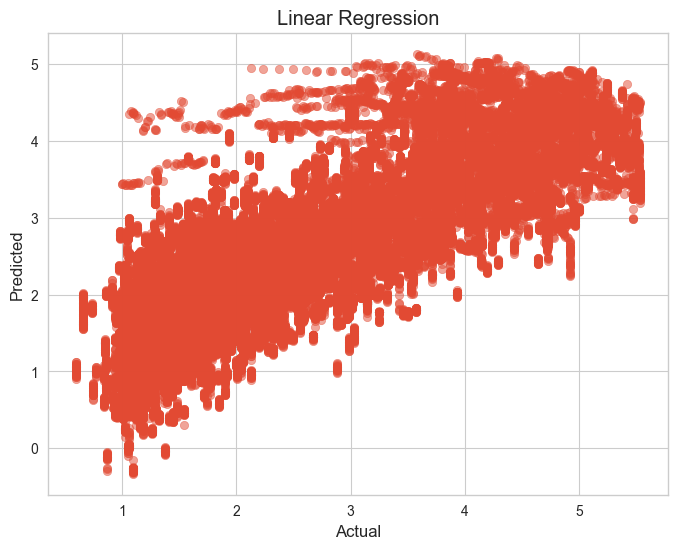

In [49]:
# ==========================================================
# ACTUAL VS PREDICTED GRAPH
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lr_pred,
    alpha=0.5
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Linear Regression")

plt.show()

In [50]:
# ==========================================================
# DECISION TREE
# ==========================================================

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [51]:
# ==========================================================
# DECISION TREE PREDICTION
# ==========================================================

dt_pred = dt_model.predict(X_test)

In [52]:
# ==========================================================
# DECISION TREE EVALUATION
# ==========================================================

dt_mae = mean_absolute_error(y_test, dt_pred)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("----------------------------")

print("MAE :", dt_mae)

print("RMSE:", dt_rmse)

print("R² :", dt_r2)

Decision Tree Results
----------------------------
MAE : 0.0019968611612411107
RMSE: 0.03882369251482052
R² : 0.9988061051011364


In [53]:
# ==========================================================
# RANDOM FOREST
# ==========================================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [54]:
# ==========================================================
# RANDOM FOREST PREDICTION
# ==========================================================

rf_pred = rf_model.predict(X_test)

In [55]:
# ==========================================================
# RANDOM FOREST EVALUATION
# ==========================================================

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("----------------------------")

print("MAE :", rf_mae)

print("RMSE:", rf_rmse)

print("R² :", rf_r2)

Random Forest Results
----------------------------
MAE : 0.0030168652082236147
RMSE: 0.02035753725986835
R² : 0.9996717362730947


In [56]:
# ==========================================================
# ACTUAL VS PREDICTED
# ==========================================================

comparison_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred
})

display(comparison_rf.head(10))

,Actual,Predicted
0,4.90,4.900000
1,1.49,1.490000
2,1.26,1.260000
3,1.98,1.980000
4,2.20,2.200000
5,1.73,1.730000
6,2.32,2.345971
7,1.84,1.840000
8,1.55,1.550000
9,3.88,3.880000


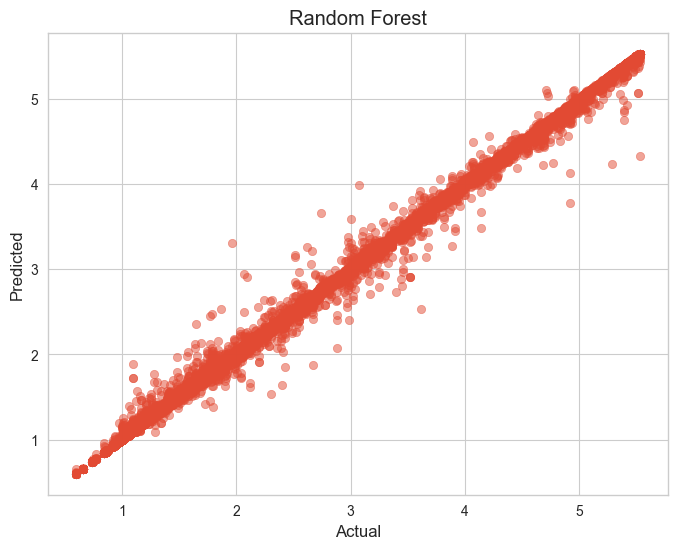

In [57]:
# ==========================================================
# RANDOM FOREST GRAPH
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Random Forest")

plt.show()

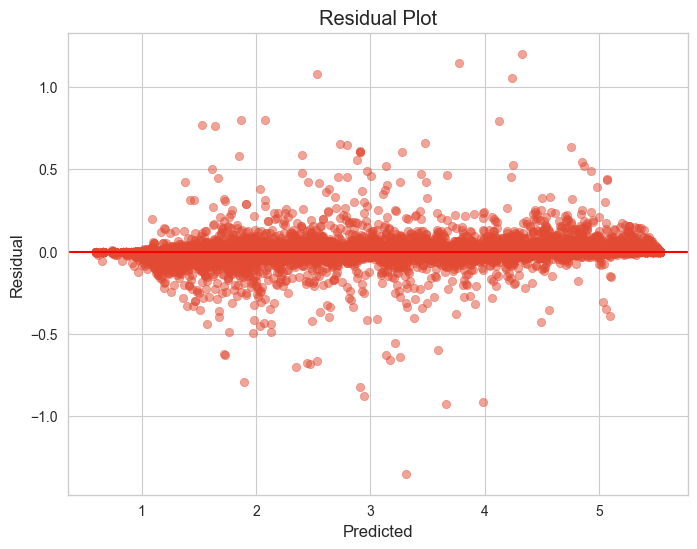

In [58]:
# ==========================================================
# RESIDUAL PLOT
# ==========================================================

residuals = y_test - rf_pred

plt.figure(figsize=(8,6))

plt.scatter(
    rf_pred,
    residuals,
    alpha=0.5
)

plt.axhline(y=0,color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [59]:
# ==========================================================
# MODEL COMPARISON
# ==========================================================

results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],

    "R2 Score":[
        lr_r2,
        dt_r2,
        rf_r2
    ]

})

display(results)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.482440,0.626604,0.689001
1,Decision Tree,0.001997,0.038824,0.998806
2,Random Forest,0.003017,0.020358,0.999672


In [60]:
# ==========================================================
# BEST MODEL
# ==========================================================

best_model = results.sort_values(
    by="R2 Score",
    ascending=False
)

display(best_model)

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.003017,0.020358,0.999672
1,Decision Tree,0.001997,0.038824,0.998806
0,Linear Regression,0.482440,0.626604,0.689001


In [61]:
# ==========================================================
# SAVE RESULTS
# ==========================================================

results.to_csv(
    "Model_Comparison.csv",
    index=False
)

print("Results Saved Successfully!")

Results Saved Successfully!


📘 PART 5: Hyperparameter Tuning & Project Objectives

In [62]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [63]:
# ==========================================================
# HYPERPARAMETER GRID
# ==========================================================

param_grid = {

    'n_estimators': [100,150,200],

    'max_depth': [10,20,30,None],

    'min_samples_split': [2,5,10],

    'min_samples_leaf': [1,2,4],

    'max_features': ['sqrt','log2']

}

print("Parameter Grid Created")

Parameter Grid Created


In [64]:
# ==========================================================
# RANDOMIZED SEARCH
# ==========================================================

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(

    estimator=rf,

    param_distributions=param_grid,

    n_iter=10,

    cv=3,

    scoring='r2',

    verbose=2,

    random_state=42,

    n_jobs=-1

)

random_search.fit(X_train, y_train)

print("Hyperparameter Tuning Completed!")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Hyperparameter Tuning Completed!


In [65]:
# ==========================================================
# BEST PARAMETERS
# ==========================================================

print("Best Parameters:")

print(random_search.best_params_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [66]:
# ==========================================================
# BEST MODEL
# ==========================================================

best_rf = random_search.best_estimator_

best_pred = best_rf.predict(X_test)

print("Best Model Ready!")

Best Model Ready!


In [67]:
# ==========================================================
# EVALUATION
# ==========================================================

best_mae = mean_absolute_error(y_test,best_pred)

best_rmse = np.sqrt(mean_squared_error(y_test,best_pred))

best_r2 = r2_score(y_test,best_pred)

print("Optimized Random Forest")

print("----------------------------")

print("MAE :",best_mae)

print("RMSE:",best_rmse)

print("R² :",best_r2)

Optimized Random Forest
----------------------------
MAE : 0.017770912561595787
RMSE: 0.03575002153657188
R² : 0.9989876631759009


In [68]:
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": best_rf.feature_names_in_,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance)

,Feature,Importance
0,% Iron Concentrate,0.524781
1,Day,0.046142
2,Hour,0.039503
3,% Silica Feed,0.036991
4,% Iron Feed,0.035398
5,Amina Flow,0.031705
6,Ore Pulp pH,0.027065
7,Flotation Column 04 Air Flow,0.025138
8,DayOfWeek,0.024269
9,Month,0.023118


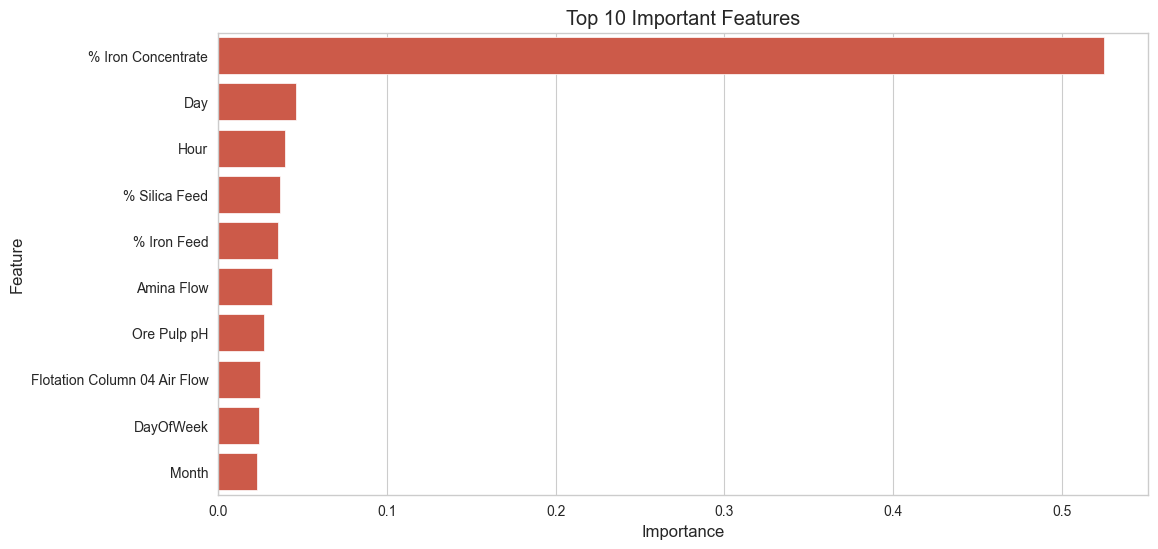

In [69]:
# ==========================================================
# FEATURE IMPORTANCE GRAPH
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [70]:
# ==========================================================
# REMOVE IRON CONCENTRATE
# ==========================================================

X_without_iron = data.drop(
    ['% Silica Concentrate',
     '% Iron Concentrate'],
    axis=1
)

y_without_iron = data['% Silica Concentrate']

print(X_without_iron.shape)

(736282, 27)


In [71]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train_noiron, X_test_noiron, y_train_noiron, y_test_noiron = train_test_split(

    X_without_iron,

    y_without_iron,

    test_size=0.20,

    random_state=42

)

In [72]:
# ==========================================================
# RANDOM FOREST
# ==========================================================

rf_without_iron = RandomForestRegressor(

    n_estimators=100,

    random_state=42,

    n_jobs=-1

)

rf_without_iron.fit(
    X_train_noiron,
    y_train_noiron
)

prediction_noiron = rf_without_iron.predict(
    X_test_noiron
)

In [73]:
# ==========================================================
# EVALUATION
# ==========================================================

mae_noiron = mean_absolute_error(
    y_test_noiron,
    prediction_noiron
)

rmse_noiron = np.sqrt(
    mean_squared_error(
        y_test_noiron,
        prediction_noiron
    )
)

r2_noiron = r2_score(
    y_test_noiron,
    prediction_noiron
)

print("Random Forest WITHOUT Iron Concentrate")

print("-------------------------------------")

print("MAE :",mae_noiron)

print("RMSE:",rmse_noiron)

print("R² :",r2_noiron)

Random Forest WITHOUT Iron Concentrate
-------------------------------------
MAE : 0.01303047612203818
RMSE: 0.06302173741127017
R² : 0.996854040242823


In [74]:
# ==========================================================
# FINAL COMPARISON
# ==========================================================

comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Decision Tree",

        "Random Forest",

        "Optimized Random Forest",

        "Random Forest (Without Iron)"

    ],

    "MAE":[

        lr_mae,

        dt_mae,

        rf_mae,

        best_mae,

        mae_noiron

    ],

    "RMSE":[

        lr_rmse,

        dt_rmse,

        rf_rmse,

        best_rmse,

        rmse_noiron

    ],

    "R² Score":[

        lr_r2,

        dt_r2,

        rf_r2,

        best_r2,

        r2_noiron

    ]

})

display(comparison)

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.482440,0.626604,0.689001
1,Decision Tree,0.001997,0.038824,0.998806
2,Random Forest,0.003017,0.020358,0.999672
3,Optimized Random Forest,0.017771,0.035750,0.998988
4,Random Forest (Without Iron),0.013030,0.063022,0.996854


In [75]:
# ==========================================================
# SAVE RESULTS
# ==========================================================

comparison.to_csv(
    "Final_Model_Comparison.csv",
    index=False
)

feature_importance.to_csv(
    "Feature_Importance.csv",
    index=False
)

print("Results Saved Successfully!")

Results Saved Successfully!


📘 PART 6: Future Prediction, Model Saving & Final Conclusions

In [76]:
# ==========================================================
# CREATE FUTURE TARGET (1 HOUR AHEAD)
# ==========================================================

future_data = data.copy()

# Shift target by 180 rows (1 hour)
future_data["Future_Silica"] = future_data["% Silica Concentrate"].shift(-180)

# Remove rows with missing future target
future_data.dropna(inplace=True)

print("Future Dataset Shape:", future_data.shape)

Future Dataset Shape: (736102, 30)


In [77]:
# ==========================================================
# CREATE FEATURES & TARGET
# ==========================================================

X_future = future_data.drop(
    ["Future_Silica"],
    axis=1
)

y_future = future_data["Future_Silica"]

print(X_future.shape)
print(y_future.shape)

(736102, 29)
(736102,)


In [78]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train_future, X_test_future, y_train_future, y_test_future = train_test_split(

    X_future,

    y_future,

    test_size=0.20,

    random_state=42

)

print("Training Shape:", X_train_future.shape)
print("Testing Shape:", X_test_future.shape)

Training Shape: (588881, 29)
Testing Shape: (147221, 29)


In [79]:
# ==========================================================
# FUTURE PREDICTION MODEL
# ==========================================================

future_rf = RandomForestRegressor(

    n_estimators=100,

    random_state=42,

    n_jobs=-1

)

future_rf.fit(
    X_train_future,
    y_train_future
)

future_prediction = future_rf.predict(
    X_test_future
)

print("Future Prediction Model Trained!")

Future Prediction Model Trained!


In [80]:
# ==========================================================
# FUTURE PREDICTION EVALUATION
# ==========================================================

future_mae = mean_absolute_error(
    y_test_future,
    future_prediction
)

future_rmse = np.sqrt(
    mean_squared_error(
        y_test_future,
        future_prediction
    )
)

future_r2 = r2_score(
    y_test_future,
    future_prediction
)

print("1 Hour Ahead Prediction")

print("-------------------------")

print("MAE :", future_mae)

print("RMSE:", future_rmse)

print("R² :", future_r2)

1 Hour Ahead Prediction
-------------------------
MAE : 0.0032946827088504243
RMSE: 0.02538631649799869
R² : 0.9994902882414217


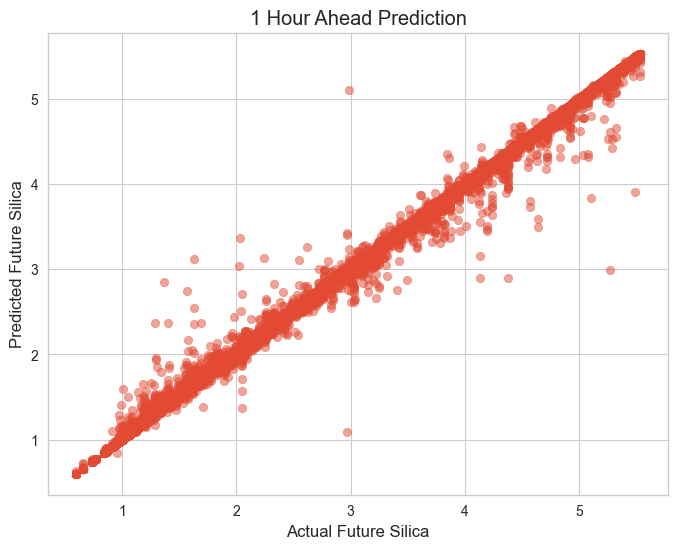

In [81]:
# ==========================================================
# ACTUAL VS FUTURE PREDICTION
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_future,
    future_prediction,
    alpha=0.5
)

plt.xlabel("Actual Future Silica")

plt.ylabel("Predicted Future Silica")

plt.title("1 Hour Ahead Prediction")

plt.show()

In [82]:
# ==========================================================
# SAVE MODELS
# ==========================================================

import joblib

joblib.dump(best_rf, "Optimized_Random_Forest.pkl")

joblib.dump(rf_without_iron, "RandomForest_Without_Iron.pkl")

joblib.dump(future_rf, "Future_Prediction_Model.pkl")

print("Models Saved Successfully!")

Models Saved Successfully!


In [83]:
# ==========================================================
# SAVE SCALER
# ==========================================================

joblib.dump(scaler, "StandardScaler.pkl")

print("Scaler Saved Successfully!")

Scaler Saved Successfully!


In [84]:
# ==========================================================
# SAVE FEATURE IMPORTANCE
# ==========================================================

feature_importance.to_csv(
    "Feature_Importance.csv",
    index=False
)

print("Feature Importance Saved!")

Feature Importance Saved!


In [85]:
# ==========================================================
# FINAL RESULTS
# ==========================================================

final_results = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Decision Tree",

        "Random Forest",

        "Optimized Random Forest",

        "Random Forest (Without Iron)",

        "Future Prediction Model"

    ],

    "MAE":[

        lr_mae,

        dt_mae,

        rf_mae,

        best_mae,

        mae_noiron,

        future_mae

    ],

    "RMSE":[

        lr_rmse,

        dt_rmse,

        rf_rmse,

        best_rmse,

        rmse_noiron,

        future_rmse

    ],

    "R² Score":[

        lr_r2,

        dt_r2,

        rf_r2,

        best_r2,

        r2_noiron,

        future_r2

    ]

})

display(final_results)

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.482440,0.626604,0.689001
1,Decision Tree,0.001997,0.038824,0.998806
2,Random Forest,0.003017,0.020358,0.999672
3,Optimized Random Forest,0.017771,0.035750,0.998988
4,Random Forest (Without Iron),0.013030,0.063022,0.996854
5,Future Prediction Model,0.003295,0.025386,0.999490
